## Multi-protocol CNN Raw CSI Experiments

This notebook runs the fixed-capacity CNN across block, LOVO, and cross-session protocols with one independent run per configured seed.

In [34]:
from __future__ import annotations

import pandas as pd
import torch

from utils.config import (
    ANCHOR_GROUPS,
    ARCHITECTURE,
    BANDS_TO_RUN,
    DATA_DIR,
    DEFAULT_CNN_PARAMS,
    DEFAULT_OVERLAP_SIZE,
    DEFAULT_WINDOW_SIZE,
    EXPECTED_ANCHORS,
    EXPECTED_SUBCARRIERS,
    SEEDS,
)
from utils.DL.dl_pipeline import (
    create_position_label_encoder,
    dl_display_model_names,
    dl_per_room_table,
    dl_seed_summary_table,
    get_cache_path,
    get_results_path,
    load_all_dl_predictions,
    prepare_dl_data,
    print_torch_environment,
    run_dl_experiments,
)
from utils.plots import (
    plot_dl_block_vs_lovo_metrics,
    plot_dl_cdf_comparison,
    plot_dl_spatial_generalization,
    plot_dl_volunteer_variability,
    plot_floor_plan_heatmap,
)

### Configuration

In [35]:
CALIBRATION_MODE = "rssi"    # ("none", "packet_norm", "rssi")

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "normalization": "empty_baseline",  # none | zscore | minmax | packet_minmax | empty_baseline
    "epsilon": 1e-8,
}
NORMALIZATION_BASELINE_SCOPE = "per_session"

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": DEFAULT_WINDOW_SIZE,
    "overlap_size": DEFAULT_OVERLAP_SIZE,
    "require_all_esps": False,
}

BLOCK_COUNT = 10
TEST_SIZE = 0.30
VALIDATION_SIZE = 0.15
RANDOM_STATE = 42
FORCE_RETRAIN = True
SPLIT_MODES = ("block",)

RUN_CLASSIFICATION = True

ANALYSIS_SEED = SEEDS[0]
ANALYSIS_MODEL = "CNN_room" if ARCHITECTURE == "room_stacked" else "CNN"
ANALYSIS_BANDS = ("Fusion",) if ARCHITECTURE == "room_stacked" else BANDS_TO_RUN
SHOW_FLOOR_PLAN = True


CNN_PARAMS = {
    **DEFAULT_CNN_PARAMS,
    "model_label": "CNN",
    "epochs": 70,
    "patience": 15,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "validation_size": VALIDATION_SIZE,
    "n_blocks": BLOCK_COUNT,
    "anchor_groups": ANCHOR_GROUPS,
    "torch_version": torch.__version__,
}

preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
preproc_opts["baseline_scope"] = NORMALIZATION_BASELINE_SCOPE
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)

feature_cache_dir = get_cache_path(preproc_opts, feat_opts)
results_dir = get_results_path()
plots_dir = results_dir / "plots"
tables_dir = results_dir / "tables"
for directory in (plots_dir, results_dir / "predictions", tables_dir):
    directory.mkdir(parents=True, exist_ok=True)


def _slugify(value: str) -> str:
    """Convert a display value to a compact filename-safe slug."""
    return value.lower().replace(".", "-").replace(" ", "-").strip("-")


analysis_plots_dir = (
    plots_dir / f"analysis_{_slugify(ANALYSIS_MODEL)}_seed-{ANALYSIS_SEED}"
)
analysis_plots_dir.mkdir(parents=True, exist_ok=True)

print(f"Feature cache path: {feature_cache_dir}")
print(f"Results path: {results_dir}")
print(f"Analysis figures path: {analysis_plots_dir}")


Feature cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0
Results path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results
Analysis figures path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/analysis_cnn_seed-42


### Environment

In [36]:
DEVICE = print_torch_environment(require_cuda=True)


torch.__version__: 2.11.0+cu128
torch.version.cuda: 12.8
torch.cuda.get_device_name(0): NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition
torch.cuda.get_device_capability(0): (12, 0)
CUDA matmul smoke test result: [[0.0, 1.0, 2.0, 3.0], [4.0, 5.0, 6.0, 7.0], [8.0, 9.0, 10.0, 11.0], [12.0, 13.0, 14.0, 15.0]] (PASS)


### Data

In [37]:
processed_magnitude_data, feature_dataframes, csv_diagnostics, magnitude_summary = prepare_dl_data(
    DATA_DIR,
    calibration_mode=CALIBRATION_MODE,
    csv_options=CSV_PROCESSING_OPTIONS,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
)
display(magnitude_summary.head())


Scenarios present: 1
Locations: 53 | Users: 6 | ESPs: 19
[Z-0 inventory]
  total Z-0 files found: 171
  Z-0 count per (user, trial):
    (user=01, trial=01): 19
    (user=01, trial=02): 19
    (user=02, trial=01): 19
    (user=03, trial=01): 19
    (user=03, trial=02): 19
    (user=04, trial=01): 19
    (user=05, trial=01): 19
    (user=05, trial=02): 19
    (user=06, trial=01): 19
  breakdown by user / esp / trial:
    user=01 esp=01 trial=01: 1
    user=01 esp=01 trial=02: 1
    user=01 esp=02 trial=01: 1
    user=01 esp=02 trial=02: 1
    user=01 esp=03 trial=01: 1
    user=01 esp=03 trial=02: 1
    user=01 esp=04 trial=01: 1
    user=01 esp=04 trial=02: 1
    user=01 esp=05 trial=01: 1
    user=01 esp=05 trial=02: 1
    user=01 esp=07 trial=01: 1
    user=01 esp=07 trial=02: 1
    user=01 esp=08 trial=01: 1
    user=01 esp=08 trial=02: 1
    user=01 esp=09 trial=01: 1
    user=01 esp=09 trial=02: 1
    user=01 esp=10 trial=01: 1
    user=01 esp=10 trial=02: 1
    user=01 esp=11 tri

,scenario,location,user,esp,trial,samples,subcarriers,normalization,baseline_scope
0,1,C-1,06,16,01,2088,56,empty_baseline,per_session
1,1,C-1,06,15,01,1942,56,empty_baseline,per_session
2,1,C-1,06,09,01,1689,50,empty_baseline,per_session
3,1,C-1,06,07,01,1965,50,empty_baseline,per_session
4,1,C-1,06,04,01,1913,50,empty_baseline,per_session


In [38]:
for band in BANDS_TO_RUN:
    df = feature_dataframes[band]
    print(f"{band}: {df.shape[0]} windows, {df.shape[1]} columns")
    print(f"{band} dataframe hash: {pd.util.hash_pandas_object(df, index=True).sum()}")


2.4 GHz: 13588 windows, 2708 columns
2.4 GHz dataframe hash: 11876030231112758796
5 GHz: 14478 windows, 3368 columns
5 GHz dataframe hash: 1871796993234382690
Fusion: 13568 windows, 6068 columns
Fusion dataframe hash: 18372045827207501857


In [39]:
label_encoder = create_position_label_encoder(
    feature_dataframes,
    results_dir=results_dir,
    expected_classes=52,
)
print(label_encoder.classes_)


[CNN] label classes saved to /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/manifests/cnn_label_classes.json
['A-1' 'A-13' 'A-14' 'A-2' 'A-5' 'B-1' 'B-10' 'B-11' 'B-12' 'B-13' 'B-14'
 'B-2' 'B-5' 'B-8' 'C-1' 'C-10' 'C-11' 'C-14' 'C-2' 'C-3' 'C-4' 'C-5'
 'C-6' 'C-7' 'C-8' 'C-9' 'D-1' 'D-2' 'D-3' 'D-4' 'D-5' 'D-6' 'D-7' 'D-8'
 'E-1' 'E-10' 'E-11' 'E-12' 'E-13' 'E-2' 'E-3' 'E-4' 'E-5' 'E-6' 'E-7'
 'E-8' 'F-10' 'F-11' 'F-12' 'F-13' 'F-5' 'F-8']


### Train And Evaluate

In [40]:
if RUN_CLASSIFICATION:
    cnn_runs = run_dl_experiments(
        processed_magnitude_data,
        feature_dataframes,
        bands=BANDS_TO_RUN,
        split_modes=SPLIT_MODES,
        label_encoder=label_encoder,
        device=DEVICE,
        results_dir=results_dir,
        plots_dir=plots_dir,
        params=CNN_PARAMS,
        preproc_opts=preproc_opts,
        feat_opts=feat_opts,
        expected_subcarriers=EXPECTED_SUBCARRIERS,
        expected_anchors=EXPECTED_ANCHORS,
        architecture=ARCHITECTURE,
        seeds=SEEDS,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        n_blocks=BLOCK_COUNT,
        val_size=VALIDATION_SIZE,
        force_retrain=FORCE_RETRAIN,
    )
else:
    print("Classification skipped because RUN_CLASSIFICATION is False.")


=== 2.4 GHz ===
[window arrays] cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/window_arrays/2_4ghz
[window arrays cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/window_arrays/2_4ghz
[window arrays] 2.4 GHz: shape=(13588, 9, 50, 60), dtype=float16
[window arrays] 2.4 GHz anchors: ['esp_01', 'esp_02', 'esp_03', 'esp_04', 'esp_05', 'esp_07', 'esp_08', 'esp_09', 'esp_10']
2.4 GHz: anchors=9, subcarriers=50, windows=13588
WINDOW IDENTITY PASS: 2.4 GHz (13588 windows)
[trial filter] split=block trials=['01'] kept=8906/13588
[protocol] split=block trials_used=['01'] n_train=4947 n_test=1392 users=['01', '02', '03', '04', '05', '06'] train_users=['01', '02', '03', '04', '05', '06'] test_users=['01', '02', '03', '04', '05', '06']
[trial filter] split=block trials=['01'] kept=8906/13588
[protocol] sp

/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:527: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  band: torch.as_tensor(array[array_index], dtype=torch.float32)
/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:527: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

[CNN] 2.4 GHz/block fold=single epoch 01/70: train_loss=3.8989 train_acc=0.0551 val_loss=3.9348 val_acc=0.1000 seconds=3.2
[CNN] 2.4 GHz/block fold=single epoch 02/70: train_loss=3.6778 train_acc=0.1009 val_loss=3.8131 val_acc=0.1067 seconds=0.2
[CNN] 2.4 GHz/block fold=single epoch 03/70: train_loss=3.4273 train_acc=0.1294 val_loss=3.5360 val_acc=0.1333 seconds=0.2
[CNN] 2.4 GHz/block fold=single epoch 04/70: train_loss=3.2065 train_acc=0.1758 val_loss=3.2015 val_acc=0.1733 seconds=0.2
[CNN] 2.4 GHz/block fold=single epoch 05/70: train_loss=3.0359 train_acc=0.1944 val_loss=3.0050 val_acc=0.1733 seconds=0.2
[CNN] 2.4 GHz/block fold=single epoch 06/70: train_loss=2.9177 train_acc=0.2157 val_loss=2.8840 val_acc=0.2000 seconds=0.2
[CNN] 2.4 GHz/block fold=single epoch 07/70: train_loss=2.8018 train_acc=0.2346 val_loss=2.8407 val_acc=0.2267 seconds=0.2
[CNN] 2.4 GHz/block fold=single epoch 08/70: train_loss=2.6992 train_acc=0.2621 val_loss=2.7179 val_acc=0.2200 seconds=0.2
[CNN] 2.4 GHz/bl

/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:527: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  band: torch.as_tensor(array[array_index], dtype=torch.float32)
/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:527: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

[predictions] Saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/predictions/dl__cnn__2_4ghz__block__ebl-session__s42__9b1404.parquet
[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/dl__cnn__2_4ghz__block__ebl-session__s42__9b1404/training_curves.pdf.
[DL GPU] run_id=dl__cnn__2_4ghz__block__ebl-session__s42__9b1404 peak_cuda_memory_bytes=514714624
[results upsert] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/runs.csv: 72 row(s)
Seeds: random=43, numpy=43, torch=43
[trial filter] split=block trials=['01'] kept=8906/13588
[protocol] split=block trials_used=['01'] n_train=4947 n_test=1392 users=['01', '02', '03', '04', '05', '06'] train_users=['01', '02', '03', '04', '05', '06'] test_users=['01', '02', '03', '04', '05', '06']
[trial filter] split=block trials=['01'] kept=4947/4947
[protocol] split=block trials_used=['01'] n_train=3014 n_test=150 users=['01', '02', '03', '04', '05', '06'] train_users=['01', '02', '03', '04', 

...

[predictions] Saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/predictions/dl__cnn__fusion__block__ebl-session__s43__a89b5d.parquet
[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/dl__cnn__fusion__block__ebl-session__s43__a89b5d/training_curves.pdf.
[DL GPU] run_id=dl__cnn__fusion__block__ebl-session__s43__a89b5d peak_cuda_memory_bytes=978418688
[results upsert] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/runs.csv: 72 row(s)
Seeds: random=44, numpy=44, torch=44
[trial filter] split=block trials=['01'] kept=8889/13568
[protocol] split=block trials_used=['01'] n_train=4934 n_test=1388 users=['01', '02', '03', '04', '05', '06'] train_users=['01', '02', '03', '04', '05', '06'] test_users=['01', '02', '03', '04', '05', '06']
[trial filter] split=block trials=['01'] kept=4934/4934
[protocol] split=block trials_used=['01'] n_train=3003 n_test=150 users=['01', '02', '03', '04', '05', '06'] train_users=['01', '02', '03', '04', 

/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:527: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  band: torch.as_tensor(array[array_index], dtype=torch.float32)
/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:527: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

[CNN] Fusion/block fold=single epoch 01/70: train_loss=3.8792 train_acc=0.0629 val_loss=3.9153 val_acc=0.0400 seconds=3.0
[CNN] Fusion/block fold=single epoch 02/70: train_loss=3.5482 train_acc=0.1252 val_loss=3.6617 val_acc=0.1267 seconds=0.4
[CNN] Fusion/block fold=single epoch 03/70: train_loss=3.1229 train_acc=0.1991 val_loss=3.1699 val_acc=0.1667 seconds=0.4
[CNN] Fusion/block fold=single epoch 04/70: train_loss=2.7860 train_acc=0.2364 val_loss=2.7768 val_acc=0.2533 seconds=0.3
[CNN] Fusion/block fold=single epoch 05/70: train_loss=2.5629 train_acc=0.2707 val_loss=2.6194 val_acc=0.2800 seconds=0.4
[CNN] Fusion/block fold=single epoch 06/70: train_loss=2.3976 train_acc=0.3037 val_loss=2.5341 val_acc=0.2533 seconds=0.3
[CNN] Fusion/block fold=single epoch 07/70: train_loss=2.2458 train_acc=0.3443 val_loss=2.3747 val_acc=0.2800 seconds=0.3
[CNN] Fusion/block fold=single epoch 08/70: train_loss=2.1212 train_acc=0.3720 val_loss=2.3012 val_acc=0.2800 seconds=0.4
[CNN] Fusion/block fold=

/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:527: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  band: torch.as_tensor(array[array_index], dtype=torch.float32)
/home/pedro.monteiro@co.it.pt/Desktop/thesis-project/utils/DL/dl_pipeline.py:527: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

[predictions] Saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/predictions/dl__cnn__fusion__block__ebl-session__s44__7b9bf2.parquet
[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/dl__cnn__fusion__block__ebl-session__s44__7b9bf2/training_curves.pdf.
[DL GPU] run_id=dl__cnn__fusion__block__ebl-session__s44__7b9bf2 peak_cuda_memory_bytes=978418688
[results upsert] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/runs.csv: 72 row(s)
[DL seeds] mean +/- std across seeds written to tables/seed_summary; LOVO uses each seed's fold mean and keeps within-seed fold std separate.


### Analysis Tables

Tables are grouped by evaluation split: Temporal Block, Leave-One-Volunteer-Out (LOVO), Cross Session, and Block versus LOVO (shown only when both splits are available). Every model is reported as **Band CNN** (band-branch architecture) or **Room CNN** (room-stacked architecture, Fusion only), and every metric is the mean +/- SD across the three training seeds.

In [41]:
# Set to False to save every figure below without rendering it inline (e.g. non-interactive/batch runs).
DISPLAY_PLOTS = True

try:
    all_cnn_predictions = load_all_dl_predictions(
        results_dir,
        bands_to_run=BANDS_TO_RUN,
        split_modes=SPLIT_MODES,
        seeds=SEEDS,
    )
except FileNotFoundError as error:
    all_cnn_predictions = pd.DataFrame()
    print(f"DL predictions unavailable: {error}")

if not all_cnn_predictions.empty:
    cnn_master_table = dl_seed_summary_table(all_cnn_predictions, seeds=SEEDS)
    cnn_per_room_table = dl_per_room_table(all_cnn_predictions, seeds=SEEDS)
else:
    cnn_master_table = pd.DataFrame()
    cnn_per_room_table = pd.DataFrame()

available_splits = set(cnn_master_table["split"].astype(str)) if not cnn_master_table.empty else set()
has_block = "block" in SPLIT_MODES and "block" in available_splits
has_lovo = "lovo" in SPLIT_MODES and "lovo" in available_splits
has_cross_session = (
    "cross_session" in SPLIT_MODES and "cross_session" in available_splits
)

print(
    f"Temporal Block available: {has_block} | LOVO available: {has_lovo} | "
    f"Cross Session available: {has_cross_session}"
)

Temporal Block available: True | LOVO available: False | Cross Session available: False


#### Temporal Block

In [42]:
if has_block:
    block_master = cnn_master_table.loc[cnn_master_table["split"] == "block"].copy()
    block_master["model"] = dl_display_model_names(block_master["model"])
    display(
        block_master[
            [
                "model",
                "dataset",
                "split",
                "n_seeds",
                "position_accuracy",
                "macro_f1",
                "room_accuracy",
                "mean_distance_error",
                "median_distance_error",
            ]
        ]
    )

    block_rooms = cnn_per_room_table.loc[cnn_per_room_table["split"] == "block"].copy()
    block_rooms["model"] = dl_display_model_names(block_rooms["model"])
    display(block_rooms[["model", "dataset", "split", "true_room", "n_seeds", "position_accuracy"]])
else:
    print("Temporal Block tables skipped: the block split is not selected or unavailable.")

,model,dataset,split,n_seeds,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error
0,Band CNN,2.4 GHz,block,3,0.3836 +/- 0.0493,0.3802 +/- 0.0513,0.8575 +/- 0.0172,2.0948 +/- 0.2486,1.1381 +/- 0.2391
1,Band CNN,5 GHz,block,3,0.3202 +/- 0.0150,0.3112 +/- 0.0147,0.9047 +/- 0.0088,1.9216 +/- 0.0755,1.4142 +/- 0.0000
2,Band CNN,Fusion,block,3,0.4731 +/- 0.0377,0.4709 +/- 0.0369,0.9215 +/- 0.0019,1.4224 +/- 0.1045,0.6667 +/- 0.5774
3,Room CNN,Fusion,block,3,0.4709 +/- 0.0060,0.4624 +/- 0.0080,0.9390 +/- 0.0040,1.4195 +/- 0.0321,1.0000 +/- 0.0000


,model,dataset,split,true_room,n_seeds,position_accuracy
0,Band CNN,2.4 GHz,block,1,3,0.3716 +/- 0.0538
1,Band CNN,2.4 GHz,block,2,3,0.4117 +/- 0.0524
2,Band CNN,2.4 GHz,block,3,3,0.3994 +/- 0.0436
3,Band CNN,5 GHz,block,1,3,0.2957 +/- 0.0115
4,Band CNN,5 GHz,block,2,3,0.3937 +/- 0.0063
5,Band CNN,5 GHz,block,3,3,0.3347 +/- 0.0438
6,Band CNN,Fusion,block,1,3,0.4625 +/- 0.0443
7,Band CNN,Fusion,block,2,3,0.5401 +/- 0.0174
8,Band CNN,Fusion,block,3,3,0.4352 +/- 0.0379
9,Room CNN,Fusion,block,1,3,0.4544 +/- 0.0042


#### Leave-One-Volunteer-Out (LOVO)

In [43]:
if has_lovo:
    lovo_master = cnn_master_table.loc[cnn_master_table["split"] == "lovo"].copy()
    lovo_master["model"] = dl_display_model_names(lovo_master["model"])
    display(
        lovo_master[
            [
                "model",
                "dataset",
                "split",
                "n_seeds",
                "position_accuracy",
                "macro_f1",
                "room_accuracy",
                "mean_distance_error",
                "median_distance_error",
            ]
        ]
    )

    lovo_rooms = cnn_per_room_table.loc[cnn_per_room_table["split"] == "lovo"].copy()
    lovo_rooms["model"] = dl_display_model_names(lovo_rooms["model"])
    display(lovo_rooms[["model", "dataset", "split", "true_room", "n_seeds", "position_accuracy"]])
else:
    print("LOVO tables skipped: the LOVO split is not selected or unavailable.")

LOVO tables skipped: the LOVO split is not selected or unavailable.


#### Cross Session

In [44]:
if has_cross_session:
    cross_session_master = cnn_master_table.loc[
        cnn_master_table["split"] == "cross_session"
    ].copy()
    cross_session_master["model"] = dl_display_model_names(cross_session_master["model"])
    display(
        cross_session_master[
            [
                "model",
                "dataset",
                "split",
                "n_seeds",
                "position_accuracy",
                "macro_f1",
                "room_accuracy",
                "mean_distance_error",
                "median_distance_error",
            ]
        ]
    )

    cross_session_rooms = cnn_per_room_table.loc[
        cnn_per_room_table["split"] == "cross_session"
    ].copy()
    cross_session_rooms["model"] = dl_display_model_names(cross_session_rooms["model"])
    display(
        cross_session_rooms[
            ["model", "dataset", "split", "true_room", "n_seeds", "position_accuracy"]
        ]
    )
else:
    print("Cross Session tables skipped: the cross_session split is not selected or unavailable.")

Cross Session tables skipped: the cross_session split is not selected or unavailable.


#### Temporal Block versus LOVO

In [45]:
if has_block and has_lovo:
    comparison_rows = []
    for _, block_row in cnn_master_table.loc[cnn_master_table["split"] == "block"].iterrows():
        lovo_row = cnn_master_table.loc[
            (cnn_master_table["split"] == "lovo")
            & (cnn_master_table["model"] == block_row["model"])
            & (cnn_master_table["dataset"] == block_row["dataset"])
        ]
        if lovo_row.empty:
            continue
        lovo_row = lovo_row.iloc[0]
        comparison_rows.append(
            {
                "model": block_row["model"],
                "dataset": block_row["dataset"],
                "block_position_accuracy_mean": block_row["position_accuracy_mean"],
                "block_position_accuracy_std": block_row["position_accuracy_std"],
                "lovo_position_accuracy_mean": lovo_row["position_accuracy_mean"],
                "lovo_position_accuracy_std": lovo_row["position_accuracy_std"],
                "generalization_gap": (
                    block_row["position_accuracy_mean"] - lovo_row["position_accuracy_mean"]
                ),
            }
        )
    block_vs_lovo_table = (
        pd.DataFrame(comparison_rows).sort_values(["dataset", "model"]).reset_index(drop=True)
    )
    block_vs_lovo_table["model"] = dl_display_model_names(block_vs_lovo_table["model"])
    display(block_vs_lovo_table)
else:
    print("Block vs LOVO comparison table skipped: both splits are required.")

Block vs LOVO comparison table skipped: both splits are required.


### Temporal Block Plots

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/dl-block-band_cnn-room_cnn-cdf_comparison.pdf.


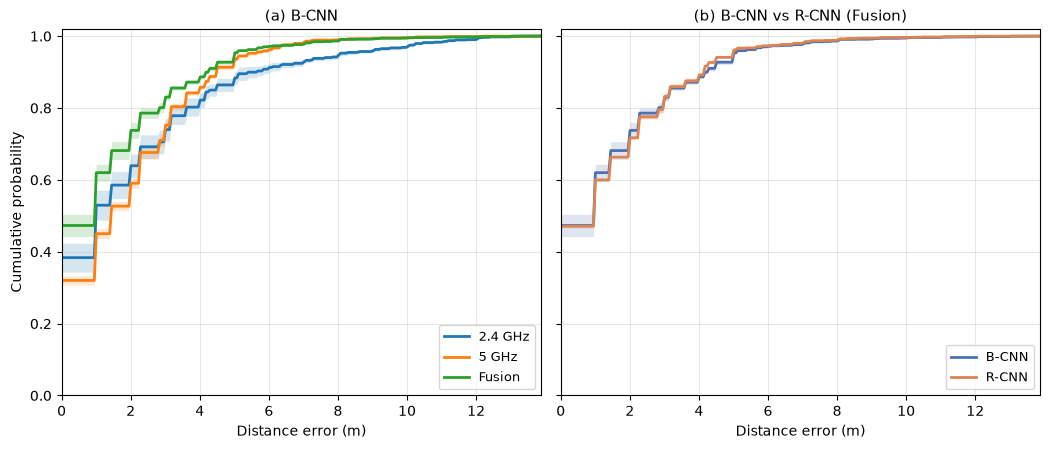

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/dl-block-band_cnn-fusion-floor_heatmap_position_accuracy.pdf.


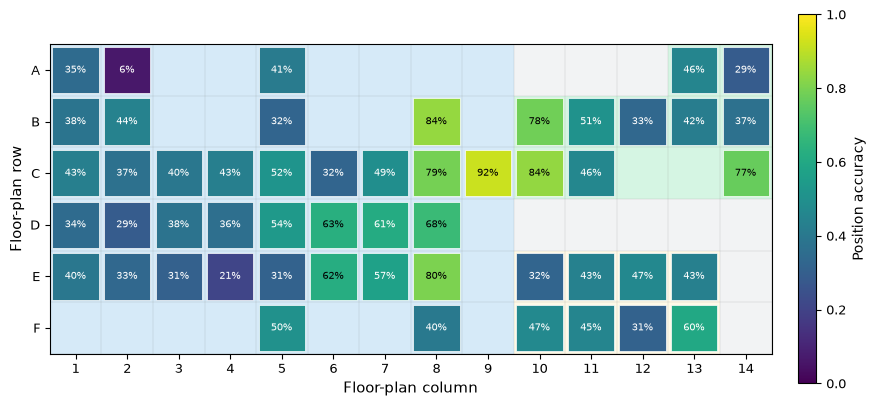

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/dl-block-band_cnn-fusion-floor_heatmap_mean_distance_error.pdf.


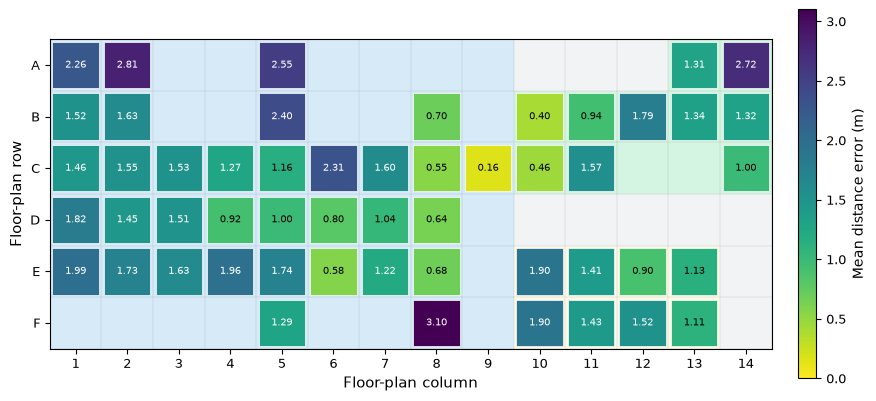

In [46]:
if has_block:
    plot_dl_cdf_comparison(
        all_cnn_predictions,
        split="block",
        seeds=SEEDS,
        band_order=BANDS_TO_RUN,
        save_path=plots_dir / "dl-block-band_cnn-room_cnn-cdf_comparison.pdf",
        show=DISPLAY_PLOTS,
    )

    if SHOW_FLOOR_PLAN:
        block_fusion_cnn_predictions = all_cnn_predictions.loc[
            (all_cnn_predictions["split_mode"] == "block")
            & (all_cnn_predictions["model"] == "CNN")
            & (all_cnn_predictions["dataset"] == "Fusion")
        ]
        # Saves two single-panel figures (position accuracy, mean distance error);
        # the model/band context belongs in the caption, not an in-figure title.
        plot_floor_plan_heatmap(
            block_fusion_cnn_predictions,
            save_path=plots_dir / "dl-block-band_cnn-fusion-floor_heatmap.pdf",
            show=DISPLAY_PLOTS,
        )
else:
    print("Temporal Block plots skipped: the block split is not selected or unavailable.")

### LOVO Plots

In [47]:
if has_lovo:
    plot_dl_cdf_comparison(
        all_cnn_predictions,
        split="lovo",
        seeds=SEEDS,
        band_order=BANDS_TO_RUN,
        save_path=plots_dir / "dl-lovo-band_cnn-room_cnn-cdf_comparison.pdf",
        show=DISPLAY_PLOTS,
    )

    plot_dl_volunteer_variability(
        all_cnn_predictions,
        seeds=SEEDS,
        band_order=BANDS_TO_RUN,
        save_path=plots_dir / "dl-lovo-band_cnn-room_cnn-volunteer_variability.pdf",
        show=DISPLAY_PLOTS,
    )

    if SHOW_FLOOR_PLAN:
        lovo_fusion_cnn_predictions = all_cnn_predictions.loc[
            (all_cnn_predictions["split_mode"] == "lovo")
            & (all_cnn_predictions["model"] == "CNN")
            & (all_cnn_predictions["dataset"] == "Fusion")
        ]
        # Saves two single-panel figures (position accuracy, mean distance error);
        # the model/band context belongs in the caption, not an in-figure title.
        plot_floor_plan_heatmap(
            lovo_fusion_cnn_predictions,
            save_path=plots_dir / "dl-lovo-band_cnn-fusion-floor_heatmap.pdf",
            show=DISPLAY_PLOTS,
        )
else:
    print("LOVO plots skipped: the LOVO split is not selected or unavailable.")

LOVO plots skipped: the LOVO split is not selected or unavailable.


### Cross Session Plots

In [48]:
if has_cross_session:
    plot_dl_cdf_comparison(
        all_cnn_predictions,
        split="cross_session",
        seeds=SEEDS,
        band_order=BANDS_TO_RUN,
        save_path=plots_dir / "dl-cross_session-band_cnn-room_cnn-cdf_comparison.pdf",
        show=DISPLAY_PLOTS,
    )

    if SHOW_FLOOR_PLAN:
        cross_session_fusion_cnn_predictions = all_cnn_predictions.loc[
            (all_cnn_predictions["split_mode"] == "cross_session")
            & (all_cnn_predictions["model"] == "CNN")
            & (all_cnn_predictions["dataset"] == "Fusion")
        ]
        # Saves two single-panel figures (position accuracy, mean distance error);
        # the model/band context belongs in the caption, not an in-figure title.
        plot_floor_plan_heatmap(
            cross_session_fusion_cnn_predictions,
            save_path=plots_dir / "dl-cross_session-band_cnn-fusion-floor_heatmap.pdf",
            show=DISPLAY_PLOTS,
        )

    # Returning-user variability: each user's position accuracy is the mean of
    # their three per-seed accuracies (seeds averaged after being computed
    # independently), matching the LOVO volunteer-variability plot above but
    # keyed on the raw "user" column instead of a held-out fold.
    plot_dl_volunteer_variability(
        all_cnn_predictions,
        seeds=SEEDS,
        band_order=BANDS_TO_RUN,
        split_mode="cross_session",
        user_column="user",
        label_prefix="Volunteer",
        save_path=plots_dir / "dl-cross_session-band_cnn-room_cnn-user_variability.pdf",
        show=DISPLAY_PLOTS,
    )
else:
    print("Cross Session plots skipped: the cross_session split is not selected or unavailable.")

Cross Session plots skipped: the cross_session split is not selected or unavailable.


### Temporal Block versus LOVO Plots

In [49]:
if has_block and has_lovo:
    plot_dl_block_vs_lovo_metrics(
        cnn_master_table,
        band_order=BANDS_TO_RUN,
        save_path=plots_dir / "dl-block_vs_lovo-band_cnn-room_cnn-metrics.pdf",
        show=DISPLAY_PLOTS,
    )

    block_fusion_cnn = all_cnn_predictions.loc[
        (all_cnn_predictions["split_mode"] == "block")
        & (all_cnn_predictions["model"] == "CNN")
        & (all_cnn_predictions["dataset"] == "Fusion")
    ]
    lovo_fusion_cnn = all_cnn_predictions.loc[
        (all_cnn_predictions["split_mode"] == "lovo")
        & (all_cnn_predictions["model"] == "CNN")
        & (all_cnn_predictions["dataset"] == "Fusion")
    ]
    plot_dl_spatial_generalization(
        block_fusion_cnn,
        lovo_fusion_cnn,
        seeds=SEEDS,
        save_path=plots_dir / "dl-block_vs_lovo-band_cnn-fusion-spatial_generalization.pdf",
        show=DISPLAY_PLOTS,
    )
else:
    print("Temporal Block vs LOVO plots skipped: both splits are required.")

Temporal Block vs LOVO plots skipped: both splits are required.
